---
title: Multivariate > Attribute-based Brand Maps
jupyter: python3
---

<div class="alert alert-info">Create brand maps based on attribute data to provide a rich visual summary of large numeric tables.</div>

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Teaching Roadmap

Attribute-based perceptual maps turn a large table of brand-by-attribute ratings into a 2-D picture. The arc of this notebook is:

1. **Summarize attribute ratings.** Many correlated attributes are reduced to a small number of factors (dimensions) using Principal Components Analysis (PCA).
2. **Read the map.** Brands become points (factor scores) and attributes become arrows (factor loadings). Learn what closeness and arrow direction mean.
3. **Add preference vectors.** Overlay how much each customer segment likes each brand to find the "ideal" direction in the map.
4. **Interpret the dimensions.** Use the attribute arrows to give the axes meaning and to spot positioning opportunities.

## The `retailers` Example

The `retailers` data set contains information on consumer evaluations for a set of retailers in the Chicago area on 7 attributes. In addition to attribute evaluations the dataset contains preference ratings on a scale from 1-9 for each retailer from two predefined consumer segments.

In [3]:
retailers = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/retailers.parquet"
)
retailers

retailer,good_value,quality_prod,service,convenience,assortment,sophisticated,cluttered,segment1,segment2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Jewel""",3.94,3.89,3.6,5.24,5.75,5.73,3.79,4.26,6.52
"""Dominick's""",4.84,4.72,4.17,5.21,5.85,5.93,3.67,4.2,6.18
"""Whole foods""",3.56,6.99,6.66,5.0,6.77,7.32,2.43,3.64,4.45
"""Cub foods""",4.03,5.78,5.56,4.56,6.0,6.29,3.42,4.12,4.07
"""Treasure Island""",6.27,1.51,2.36,4.17,3.54,2.73,5.48,8.08,2.42
"""Wal-Mart""",7.08,2.75,3.47,3.76,3.47,3.34,4.84,7.87,2.1


We use the `retailer` variable as the `brand` argument. This is simply a list of retailer names/labels. We select the variables `good_value` through `cluttered` as the `attr` (Attributes) argument, using the `start:end` range shorthand. We choose the `segment1` and `segment2` variables as the `pref` (Preferences) argument. In the Radiant GUI you would change these settings and press `Estimate`; in Python the call below performs the equivalent estimation when the object is created.

In [4]:
pm = rsm.multivariate.prmap(
    {"retailers": retailers},
    brand="retailer",
    attr="good_value:cluttered",
    pref=["segment1", "segment2"],
)
pm.summary()

Attribute based brand map
Data        : retailers
Attributes  : good_value, quality_prod, service, convenience, assortment, sophisticated, cluttered
Preferences : segment1, segment2
Dimensions  : 2
Rotation    : varimax
Observations: 6
Correlation : Pearson

Brand - Factor scores:
shape: (6, 3)
┌─────────────────┬───────┬───────┐
│ brand           ┆ RC1   ┆ RC2   │
│ ---             ┆ ---   ┆ ---   │
│ str             ┆ f64   ┆ f64   │
╞═════════════════╪═══════╪═══════╡
│ Cub foods       ┆ 0.9   ┆ -0.18 │
│ Dominick's      ┆ -0.24 ┆ 0.8   │
│ Jewel           ┆ -0.68 ┆ 1.24  │
│ Treasure Island ┆ -1.25 ┆ -0.51 │
│ Wal-Mart        ┆ -0.16 ┆ -1.57 │
│ Whole foods     ┆ 1.44  ┆ 0.22  │
└─────────────────┴───────┴───────┘

Attribute - Factor loadings:
shape: (7, 3)
┌───────────────┬───────┬───────┐
│               ┆ RC1   ┆ RC2   │
│ ---           ┆ ---   ┆ ---   │
│ str           ┆ f64   ┆ f64   │
╞═══════════════╪═══════╪═══════╡
│ good_value    ┆ -0.58 ┆ -0.77 │
│ quality_prod  ┆ 0.91  

### Reading the summary

The variables in the `attr` argument are analyzed using factor analysis (PCA with a varimax rotation) and the output is shown above. We start with a 2-dimensional solution.

- **Brand factor scores.** The first table shows the factor scores for the brands. In essence these are a weighted average of the original attribute data, where the weights are the factor loadings. In other words, the factor scores are (two) variables created by factor analysis to summarize the information contained in the original 7 attributes. These scores are the coordinates of each brand in the map.
- **Attribute factor loadings.** The second table of numbers shows the factor loadings. These represent the correlations between the original attributes and the derived factor scores. They determine the direction of each attribute arrow.
- **Fit measures.** We are also provided with information on how much of the information contained in the attributes is captured by the two derived factors. The first factor captures 56.4% and factor two captures 42% of the variation in the original data. Together the factors cover 98.4% of the variation, i.e., the information loss from reducing the dimensionality of the data from 7 attributes to two factors is only 1.6%. Adding a third factor would increase the captured variance only slightly but would make the interpretation of the map(s) more difficult. Therefore we focus on the 2-dimensional brand map.
- **Preference correlations.** The preference correlations indicate how strongly the preference scores provided by respondents are linked to the uncovered factor scores. The preferences for `segment2` seem very strongly positively correlated with factor 2 so we might expect to see the preference arrow for this segment pointing almost straight up. The communalities indicate how much of the variation in the segment preferences can be explained by the two factors. The numbers are excellent (i.e., 97.5% for Segment 1 and 91.5% for Segment 2). We can infer from these numbers that the attributes selected in the study reflect consumers' preferences well, a key feature of useful brand mapping research. Choosing attributes that are not linked to customer preferences leads to brand maps that are of limited value to a manager.
- **Attribute communalities.** The final table shows the attribute communalities. These numbers indicate how much of the variation in the attribute data can be explained by the two factors. The cumulative variance mentioned earlier is an overall measure across attributes. However, we are also interested to see if each of the individual attributes is well represented by the two factors. The numbers in this example are excellent across the board (i.e., all over 90%).

Every table you see above is also available as a Polars DataFrame on the fitted object, which is handy for further analysis:

In [5]:
pm.scores  # brand coordinates (factor scores)

brand,RC1,RC2
str,f64,f64
"""Cub foods""",0.898098,-0.180551
"""Dominick's""",-0.239553,0.80346
"""Jewel""",-0.683946,1.243077
"""Treasure Island""",-1.253986,-0.512138
"""Wal-Mart""",-0.15948,-1.570757
"""Whole foods""",1.438867,0.216909


In [6]:
pm.loadings  # attribute loadings (arrow directions)

array([[-0.57781384, -0.77448689],
       [ 0.9136022 ,  0.40122836],
       [ 0.97672603,  0.20647346],
       [ 0.20880781,  0.96920212],
       [ 0.69425   ,  0.71831176],
       [ 0.76858651,  0.63565698],
       [-0.84238165, -0.5260215 ]])

In [7]:
pm.pref_cor  # preference correlations with the factor scores

pref,RC1,RC2,communalities
str,f64,f64,f64
"""segment1""",-0.625323,-0.764223,0.975064
"""segment2""",0.08144,0.952916,0.914682


In [8]:
print("eigenvalues:", pm.eigen)
pm.communality  # attribute communalities (arrow lengths)

eigenvalues: [ 6.14007600e+00  7.47899738e-01  9.21451018e-02  1.16403831e-02
  8.23877290e-03  9.95428712e-17 -5.06444719e-16]


array([0.93369877, 0.99565317, 0.99662503, 0.98295345, 0.99795485,
       0.99478501, 0.98630545])

## Building the Map Step by Step

### Step 1 — Brands only

It is useful to start with a map showing only brand locations. We do this by requesting only the `brand` plot. The graph is a scatter plot of the scores for factor 1 (the horizontal axis) and factor 2 (the vertical axis). In other words, the scores for a brand on factor 1 and factor 2 are the coordinates for that brand in the map. The retailer names are used to label each point. The axes are square and centered on the origin so that distances are comparable in every direction.

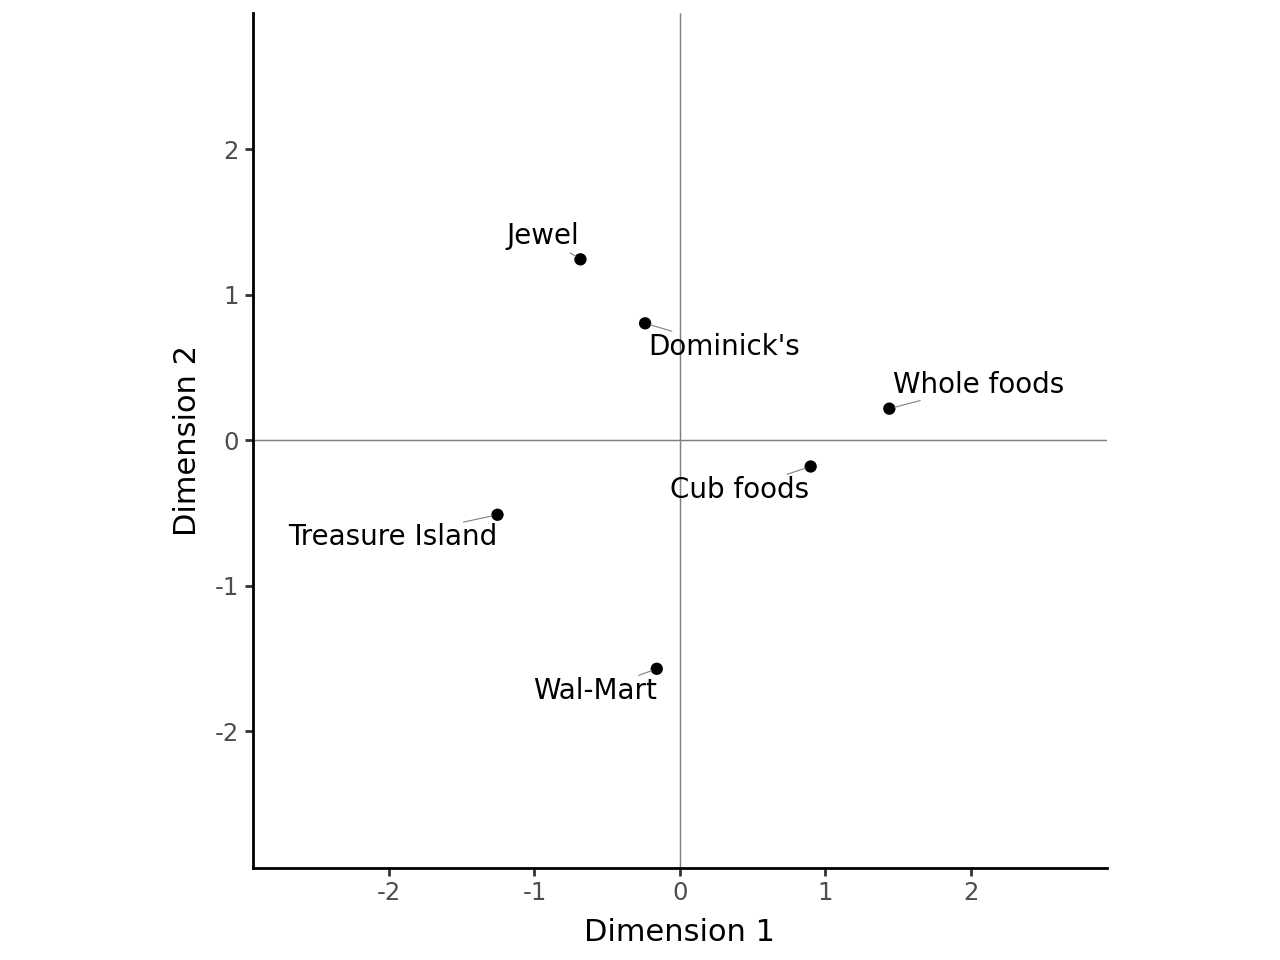

In [9]:
pm.plot(plots=["brand"])

Brands that are close together in the map are perceived as similar on the attributes for which we have data. A manager might conclude that brands that are closest together are perceived as close substitutes and, hence, close competitors in the minds of consumers.

### Step 2 — Add the attribute arrows

We create a brand map with both the brand locations (using the factor scores) and the attribute arrows (using the factor loadings) by requesting both the `brand` and `attr` plots. The attribute arrows are drawn in dark blue.

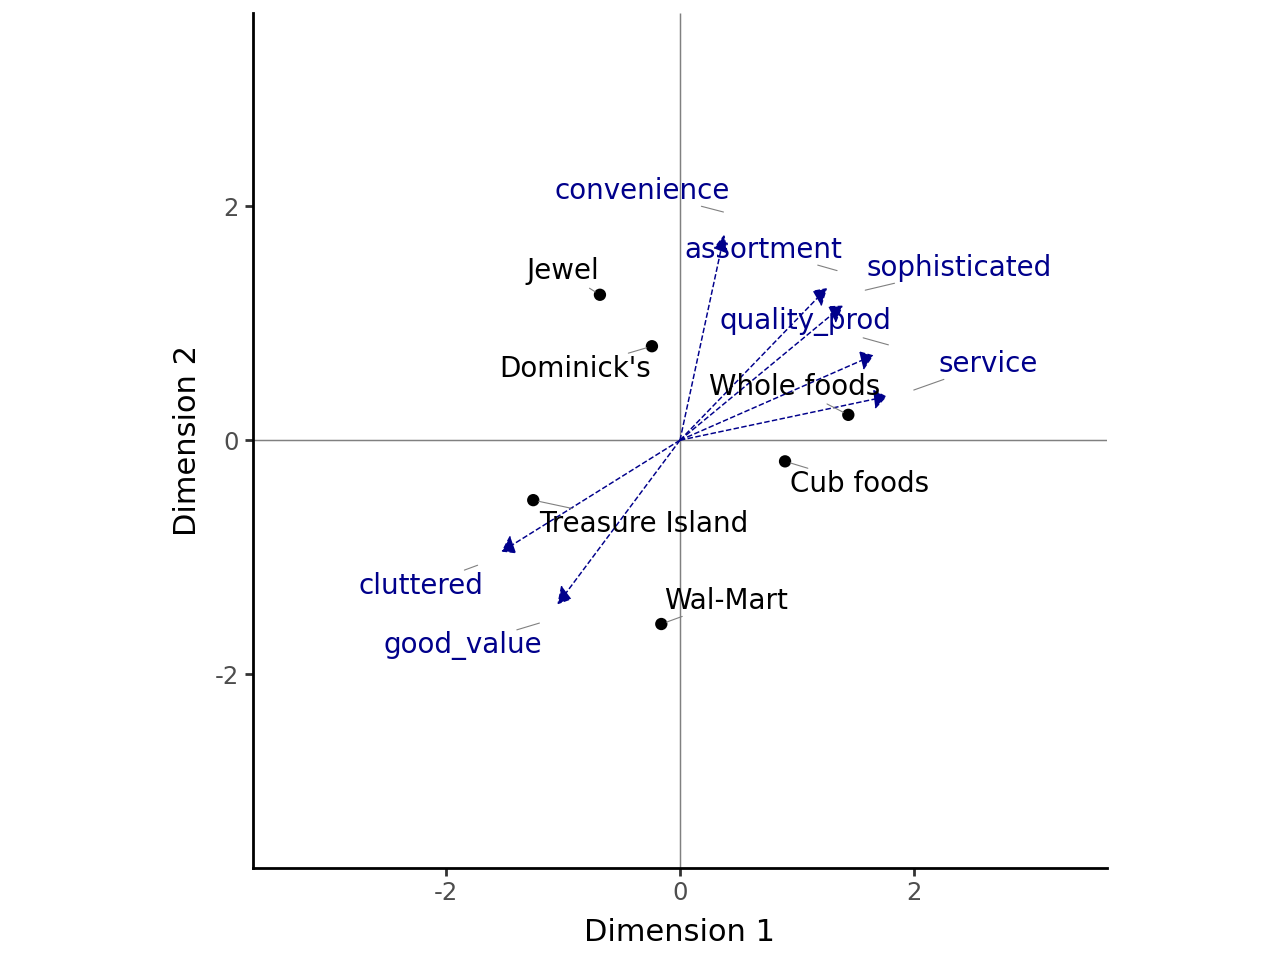

In [10]:
pm.plot(plots=["brand", "attr"])

The orientation of the arrows is determined by the degree of correlation between attribute and factors, i.e., the factor loadings. The attribute `service` has a strong positive loading on factor 1 and so it points, mostly, in the direction in which factor 1 increases in value (i.e., to the right). Since the correlation of `service` with factor 2 is, slightly, positive the arrow points up rather than down. In contrast, the attribute `convenience` has a strong positive loading on factor 2 and so it points, mostly, in the direction in which factor 2 increases in value (i.e., up). Since its correlation with factor 1 is, slightly, positive the arrow points to the right rather than to the left.

The length of the arrows is proportional to the communalities reported in the summary. The higher the communality, the longer the arrow. If an attribute is not well summarized in the derived factors its communality will be low and the arrow in the brand map for that attribute will be short.

An important limitation of a map without attribute information (e.g., a map based on (dis)similarity data) is that it is difficult to interpret why brands are located close together or far apart. By adding the attribute arrows to the map, our understanding of the brand positions in the map is significantly enhanced. For example, Jewel and Dominick's are positioned higher in the map because they are perceived to offer consumers higher levels of convenience. Similarly, Cub foods, and particularly Whole foods, offer higher levels of customer service and quality products.

### Step 3 — Add the preference arrows

Finally, we add the preference information to the map by requesting the `pref` plot as well. The preference arrows are drawn in red.

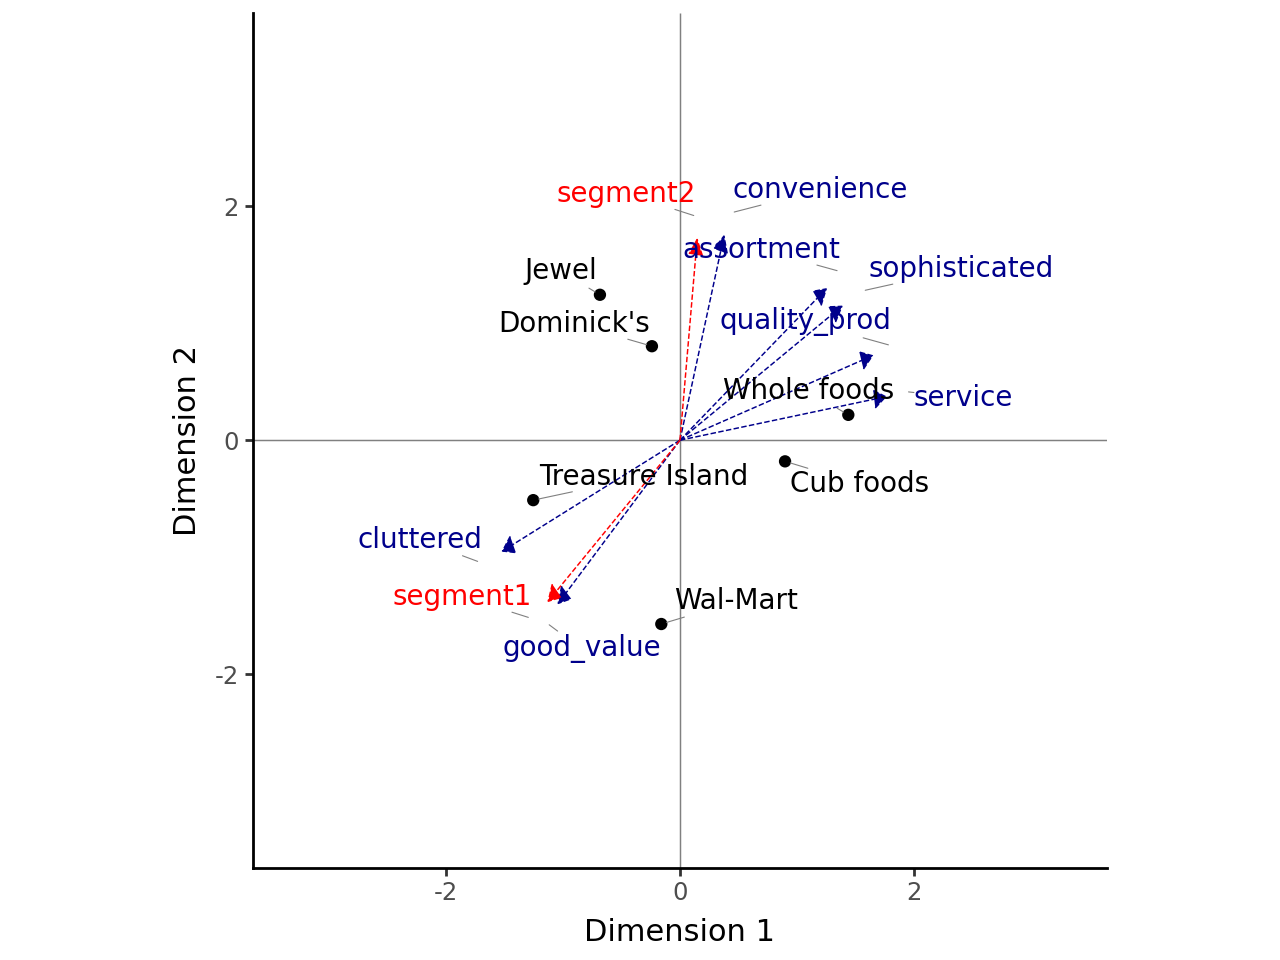

In [11]:
pm.plot(plots=["brand", "attr", "pref"])

The orientation of the segment preference arrows is determined by the correlation between the factor scores and the preference scores. Since the preferences for the retailers expressed by respondents assigned to segment 2 are highly correlated with factor 2, the arrow points almost straight up. The negative correlations of the preference scores for segment 1 with both factor 1 and factor 2 ensure that arrow will point down and to the left.

We can also infer which available attributes are most strongly linked to consumer preferences. Segment 2 is primarily concerned with Convenience, which may explain the higher preference scores for Jewel and Dominick's. Similarly, Segment 1 cares most about Good value and very little for Assortment; this segment prefers to shop at Treasure Island and Wal-Mart.

The `scaling` argument controls how long the arrows are drawn relative to the brand points (it does not change the underlying analysis, only the visual length). Increase it to make short arrows easier to read.

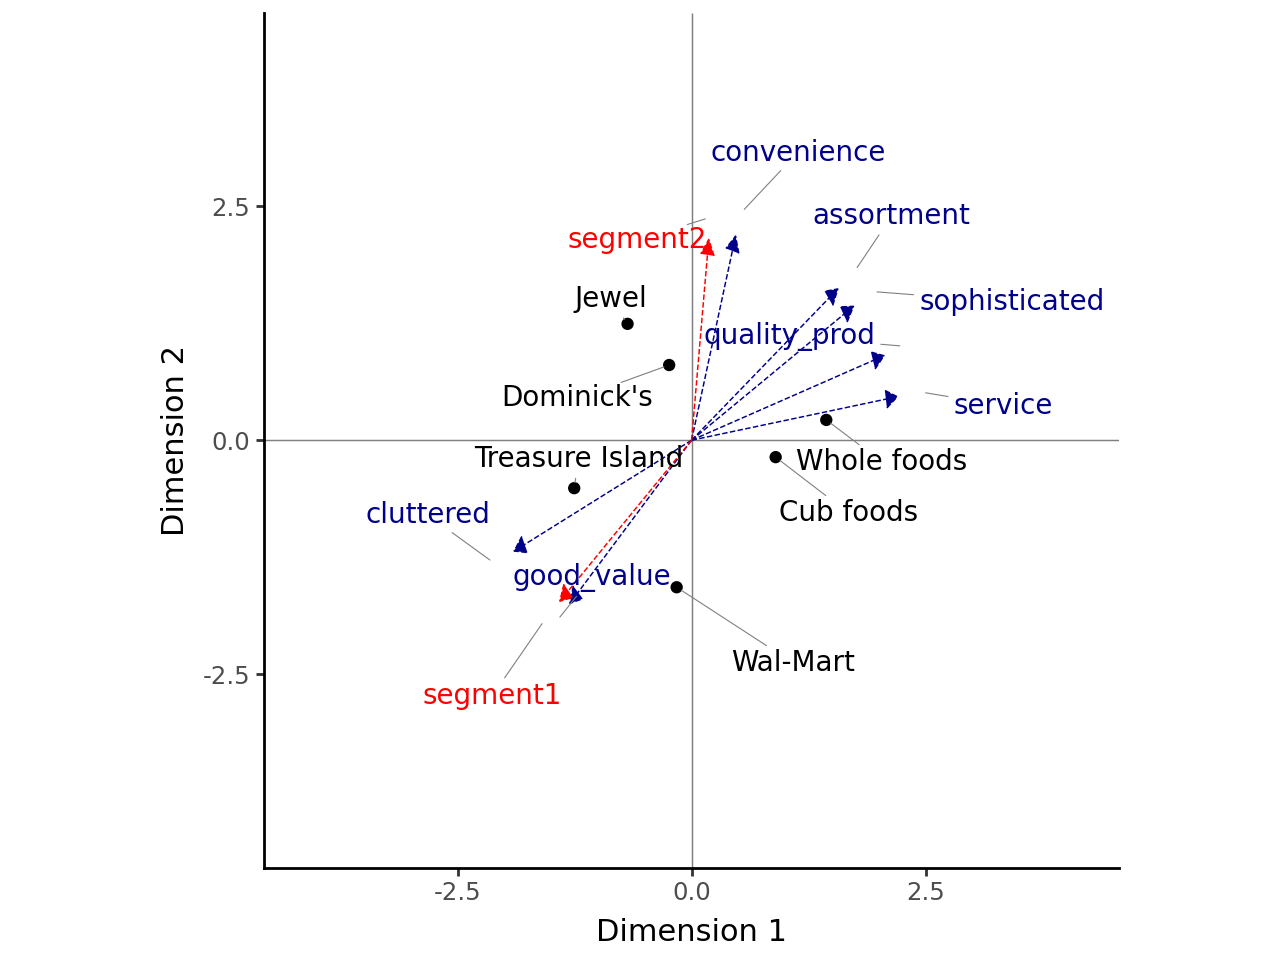

In [12]:
pm.plot(plots=["brand", "attr", "pref"], scaling=2.5)

## A Second Example: `computer`

The `computer` dataset rates five computer brands on seven attributes (`high_end` through `business`). It has no preference variables, so the map is built from brands and attributes only. This is a good example to practice reading a fresh map.

In [13]:
computer = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/computer.parquet"
)
computer

brand,high_end,stylish,modern,value,dated,innovative,business
str,f64,f64,f64,f64,f64,f64,f64
"""Apple""",5.704,6.009,6.038,2.773,3.149,4.765,4.023
"""Dell""",4.809,3.792,4.365,5.123,4.292,2.558,4.069
"""Gateway""",3.119,3.27,2.776,5.983,5.079,2.27,2.934
"""HP""",3.621,4.156,3.765,4.093,4.879,2.871,5.63
"""Sony""",5.584,5.461,5.177,3.103,3.275,2.968,3.532


In [14]:
pm_comp = rsm.multivariate.prmap(
    {"computer": computer}, brand="brand", attr="high_end:business"
)
pm_comp.summary()

Attribute based brand map
Data        : computer
Attributes  : high_end, stylish, modern, value, dated, innovative, business
Dimensions  : 2
Rotation    : varimax
Observations: 5
Correlation : Pearson

Brand - Factor scores:
shape: (5, 3)
┌─────────┬───────┬───────┐
│ brand   ┆ RC1   ┆ RC2   │
│ ---     ┆ ---   ┆ ---   │
│ str     ┆ f64   ┆ f64   │
╞═════════╪═══════╪═══════╡
│ Apple   ┆ 1.3   ┆ 0.09  │
│ Dell    ┆ -0.32 ┆ -0.21 │
│ Gateway ┆ -1.19 ┆ -0.93 │
│ HP      ┆ -0.52 ┆ 1.65  │
│ Sony    ┆ 0.73  ┆ -0.6  │
└─────────┴───────┴───────┘

Attribute - Factor loadings:
shape: (7, 3)
┌────────────┬───────┬───────┐
│            ┆ RC1   ┆ RC2   │
│ ---        ┆ ---   ┆ ---   │
│ str        ┆ f64   ┆ f64   │
╞════════════╪═══════╪═══════╡
│ high_end   ┆ 0.94  ┆ -0.16 │
│ stylish    ┆ 0.98  ┆ 0.06  │
│ modern     ┆ 0.99  ┆ 0.03  │
│ value      ┆ -0.93 ┆ -0.28 │
│ dated      ┆ -0.97 ┆ 0.21  │
│ innovative ┆ 0.86  ┆ 0.19  │
│ business   ┆ 0.02  ┆ 0.99  │
└────────────┴───────┴───────┘

Fit m

Here factor 1 captures over 76% and factor 2 about 17% of the variation, for a cumulative 93%. Looking at the loadings, factor 1 contrasts modern/stylish/high-end brands against dated/value-oriented ones, while factor 2 is dominated almost entirely by the `business` attribute. That gives the two dimensions clear interpretations.

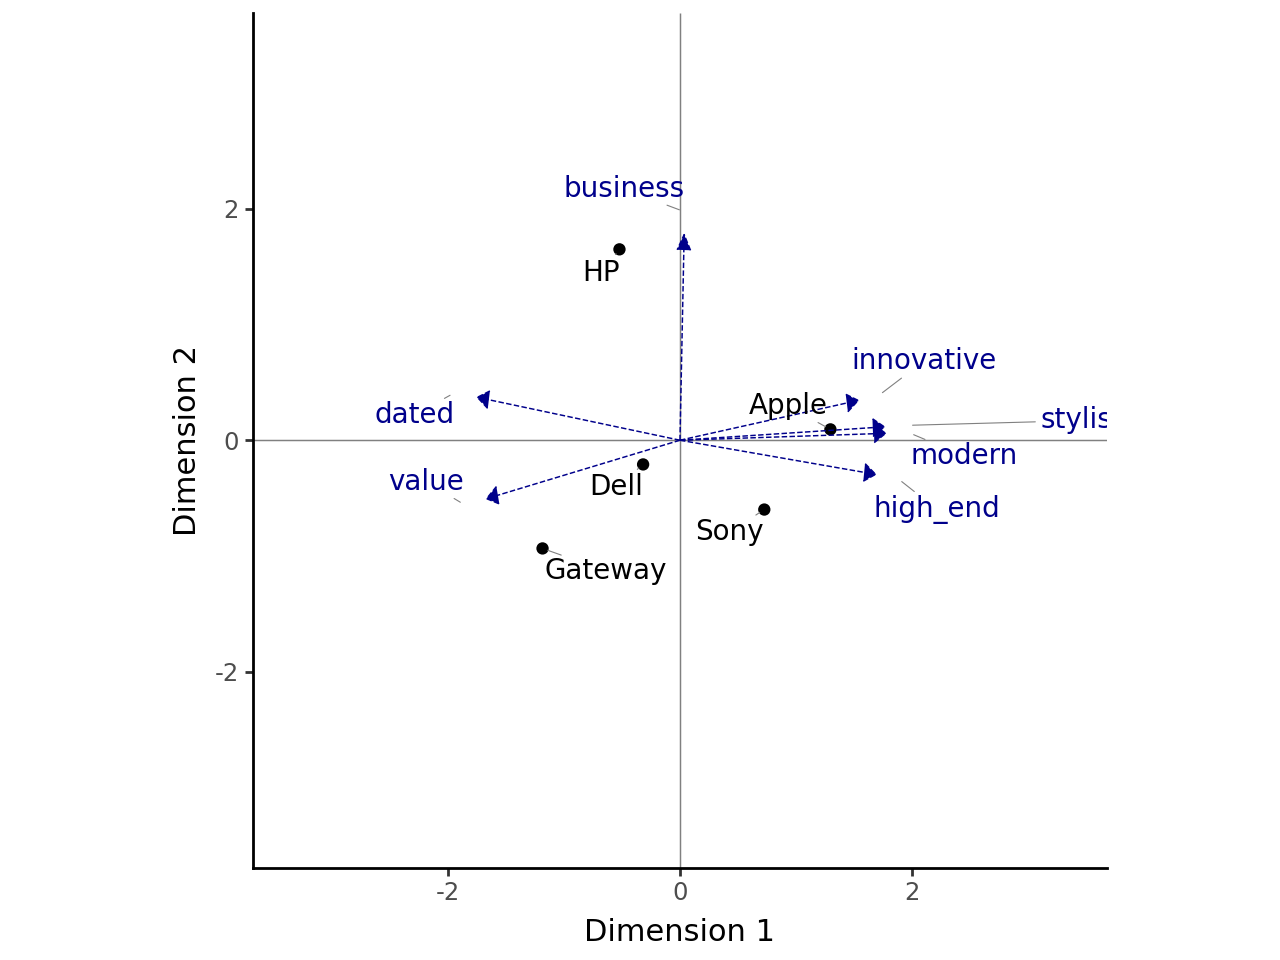

In [15]:
pm_comp.plot(plots=["brand", "attr"])

Apple sits far to the right (high on style/modern/high-end), while Gateway sits to the lower left (more dated/value). HP stands out high on factor 2, reflecting its strong `business` orientation. The `business` arrow points almost straight up because that attribute loads almost exclusively on factor 2.

## Including Categorical Variables

Attribute-based perceptual maps are calculated using Principal Components Analysis (PCA). The correlation matrix used as input for PCA can currently be calculated only for variables of type `numeric`, `integer`, and `date`. Preference information, however, can be of type `numeric`, `integer`, `date`, and categorical (factor). When categorical preference variables are included, set `hcor=True`. Correlations between the factor scores and the preference data will then be calculated using a heterogeneous-correlation approach (`polycor::hetcor` in R): the categorical variables are treated as (ordinal) categorical and all other variables are treated as continuous.

```python
# example: categorical preference variables
pm_cat = rsm.multivariate.prmap(
    {"retailers": retailers},
    brand="retailer",
    attr="good_value:cluttered",
    pref=["segment1", "segment2"],
    hcor=True,
)
```

## Choosing the Number of Dimensions

By default `prmap` extracts a 2-dimensional solution (`nr_dim=2`), which is what we plot. You can request additional dimensions to check how much extra variance they capture before settling on a 2-D map for interpretation. Use the eigenvalues and cumulative variance to decide; a third dimension that adds little explained variance is usually not worth the added interpretation difficulty.

In [16]:
pm3 = rsm.multivariate.prmap(
    {"retailers": retailers},
    brand="retailer",
    attr="good_value:cluttered",
    pref=["segment1", "segment2"],
    nr_dim=3,
)
print("eigenvalues:", pm3.eigen)
pm3.loadings

eigenvalues: [ 6.14007600e+00  7.47899738e-01  9.21451018e-02  1.16403831e-02
  8.23877290e-03  9.95428712e-17 -5.06444719e-16]


array([[-0.55199188, -0.72276766, -0.41545284],
       [ 0.91612528,  0.38460642,  0.10322718],
       [ 0.97095402,  0.18243814,  0.14410388],
       [ 0.22802237,  0.97264852,  0.02464786],
       [ 0.69437226,  0.6965865 ,  0.17501355],
       [ 0.77270958,  0.61901233,  0.12654793],
       [-0.84987641, -0.514176  , -0.07853053]])

The first two factors already explain almost all of the variation in the `retailers` attributes, so a 2-dimensional map is the right choice for interpretation here.

## Discussion Prompts

- Which retailers "own" which attributes? Identify the attribute arrow each brand sits nearest to.
- Where are the gaps in the map (regions with no brands but with a strong preference arrow pointing into them)? Those are positioning opportunities.
- Why is the absolute orientation of a PCA map arbitrary? (Hint: rotations and axis flips do not change the relative positions of brands and arrows.)
- For the `computer` data, give each axis a one-word name based on the attribute loadings, then describe Apple's and Gateway's positioning in plain language.

## Key Object Attributes

The fitted `prmap` object exposes everything shown above as Polars DataFrames / arrays:

- `pm.scores` — brand coordinates (averaged factor scores)
- `pm.loadings` — attribute loadings (arrow directions)
- `pm.communality` — attribute communalities (arrow lengths)
- `pm.eigen` — eigenvalues of the correlation matrix
- `pm.pref_cor` — correlations of preferences with the factor scores
- `pm.nr_dim` — number of dimensions extracted
- `pm.hcor` — whether heterogeneous correlations were used (for categorical preferences)